# Нейронная сеть прямого распространения (регрессия)

## Теория

**Многослойный персептрон (MLP)** для задачи регрессии имеет ту же архитектуру, что и для классификации: входной слой, один или несколько скрытых слоёв с нелинейными функциями активации, и выходной слой. Ключевое отличие — **выходной слой содержит один нейрон с линейной функцией активации** (без softmax), что позволяет предсказывать непрерывные значения любого диапазона.

### Функция потерь

Для регрессии используется **среднеквадратичная ошибка (MSE)**:

$$L = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

где $y_i$ — истинное значение, $\hat{y}_i$ — предсказанное значение, $n$ — число объектов.

### Ключевые отличия регрессии от классификации

| Аспект | Классификация | Регрессия |
|---|---|---|
| Функция активации выходного слоя | softmax / sigmoid | линейная (нет активации) |
| Функция потерь | кросс-энтропия | MSE |
| Размер выходного слоя | число классов | 1 нейрон |
| Метрики качества | accuracy, F1 | MAE, RMSE, R² |

### Ключевые гиперпараметры MLPRegressor

| Гиперпараметр | Значение по умолчанию | Описание |
|---|---|---|
| **hidden_layer_sizes** | `(100,)` | Количество нейронов в каждом скрытом слое (кортеж) |
| **activation** | `'relu'` | Функция активации скрытых слоёв: `'relu'`, `'tanh'`, `'logistic'` |
| **solver** | `'adam'` | Алгоритм оптимизации: `'adam'`, `'sgd'`, `'lbfgs'` |
| **learning_rate_init** | `0.001` | Начальная скорость обучения (для adam и sgd) |
| **max_iter** | `200` | Максимальное число эпох обучения |
| **alpha** | `0.0001` | Коэффициент L2-регуляризации (штраф за большие веса) |

## Датасет

В работе используется датасет **California Housing** из библиотеки `sklearn`.

Датасет содержит агрегированные данные переписи населения Калифорнии 1990 года по жилым кварталам (блокам):
- **20640 объектов** — жилые кварталы,
- **8 признаков** — социально-демографические и географические характеристики квартала,
- **целевая переменная** — медианная стоимость дома (в сотнях тысяч долларов США).

### Описание признаков

| Признак | Название | Описание |
|---|---|---|
| **MedInc** | медианный доход | медианный доход домохозяйств в блоке |
| **HouseAge** | возраст дома | медианный возраст домов в блоке |
| **AveRooms** | среднее комнат | среднее число комнат на домохозяйство |
| **AveBedrms** | среднее спален | среднее число спален на домохозяйство |
| **Population** | население | численность населения блока |
| **AveOccup** | среднее жильцов | среднее число жильцов на домохозяйство |
| **Latitude** | широта | географическая широта |
| **Longitude** | долгота | географическая долгота |

**Целевая переменная:** медианная стоимость дома (в сотнях тысяч $)

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и компоненты `sklearn` для обучения MLP-регрессора, масштабирования признаков и оценки качества регрессии


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

print("Форма матрицы признаков X:", X.shape)
print("Форма целевой переменной y:", y.shape)
print("\nНазвания признаков:", housing.feature_names)

Форма матрицы признаков X: (20640, 8)
Форма целевой переменной y: (20640,)

Названия признаков: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [4]:
df = pd.DataFrame(X, columns=housing.feature_names)
df['MedHouseVal'] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


## Тепловая карта

Строим тепловую карту корреляций между признаками датасета `California Housing`


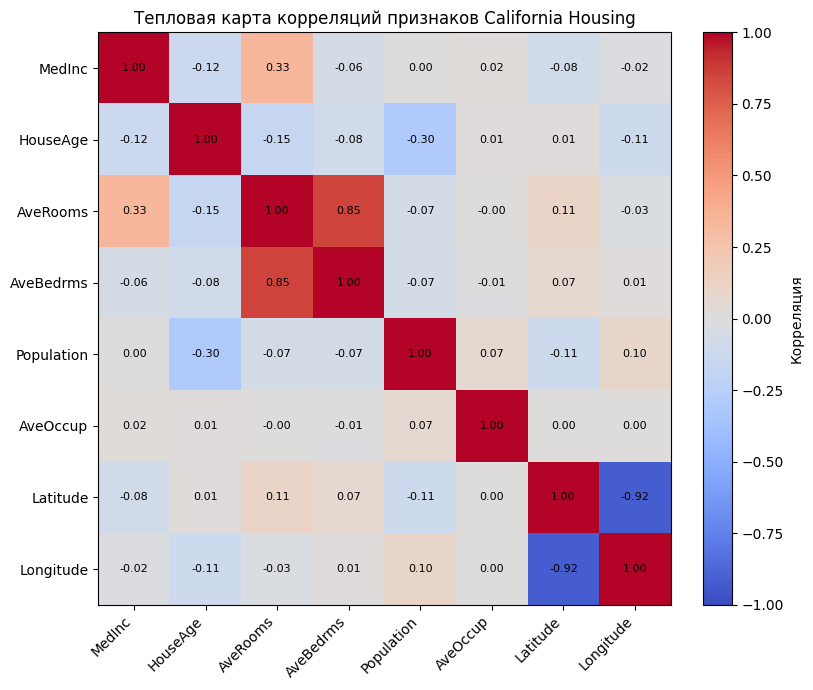

In [6]:
heatmap_features = list(housing.feature_names)
if len(heatmap_features) > 12:
    heatmap_features = heatmap_features[:12]

corr_matrix = df[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков California Housing')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


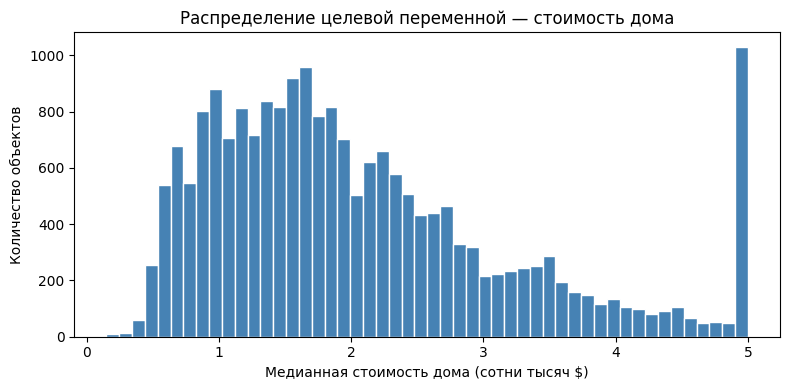

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(y, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Медианная стоимость дома (сотни тысяч $)')
plt.ylabel('Количество объектов')
plt.title('Распределение целевой переменной — стоимость дома')
plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка: ", X_test.shape)

Обучающая выборка: (16512, 8)
Тестовая выборка:  (4128, 8)


## Масштабирование

Используем `StandardScaler` для признаков и целевой переменной. После предсказаний применяем обратное преобразование.

In [9]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print("Среднее X_train_scaled (ожидается ~0):", X_train_scaled.mean(axis=0).round(4))
print("Стд. отклонение X_train_scaled (ожидается ~1):", X_train_scaled.std(axis=0).round(4))

Среднее X_train_scaled (ожидается ~0): [-0. -0.  0. -0. -0. -0.  0. -0.]
Стд. отклонение X_train_scaled (ожидается ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## Обучение MLP-регрессора

In [10]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train_scaled)
print("Обучение завершено. Число эпох:", mlp.n_iter_)

Обучение завершено. Число эпох: 123


In [11]:
y_pred_scaled = mlp.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Метрики качества базовой модели (128, 64):")
print(f"  MAE  = {mae:.4f}")
print(f"  MSE  = {mse:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  R²   = {r2:.4f}")

Метрики качества базовой модели (128, 64):
  MAE  = 0.3459
  MSE  = 0.2648
  RMSE = 0.5146
  R²   = 0.7979


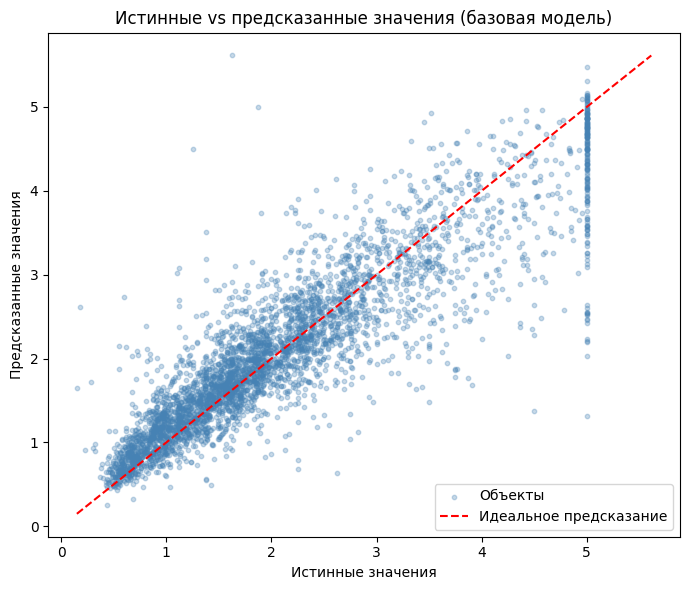

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue', label='Объекты')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Идеальное предсказание')

plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Истинные vs предсказанные значения (базовая модель)')
plt.legend()
plt.tight_layout()
plt.show()

## Влияние архитектуры

Сравним несколько конфигураций скрытых слоёв: от одного небольшого слоя до трёхслойной сети.

In [13]:
architectures = [
    (64,),
    (128,),
    (128, 64),
    (256, 128, 64),
]

arch_results = []

for arch in architectures:
    model = MLPRegressor(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train_scaled)
    
    y_pred_s = model.predict(X_test_scaled)
    y_pred_a = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    
    r2_a = r2_score(y_test, y_pred_a)
    rmse_a = np.sqrt(mean_squared_error(y_test, y_pred_a))
    
    arch_results.append({
        'Архитектура': str(arch),
        'R²': round(r2_a, 4),
        'RMSE': round(rmse_a, 4)
    })
    print(f"  Архитектура {str(arch):20s} — R² = {r2_a:.4f}, RMSE = {rmse_a:.4f}")

df_arch = pd.DataFrame(arch_results)
print("\nСравнительная таблица архитектур:")
df_arch

  Архитектура (64,)                — R² = 0.7705, RMSE = 0.5484


  Архитектура (128,)               — R² = 0.7606, RMSE = 0.5601


  Архитектура (128, 64)            — R² = 0.7979, RMSE = 0.5146


  Архитектура (256, 128, 64)       — R² = 0.7617, RMSE = 0.5588

Сравнительная таблица архитектур:


,Архитектура,R²,RMSE
0,"(64,)",0.7705,0.5484
1,"(128,)",0.7606,0.5601
2,"(128, 64)",0.7979,0.5146
3,"(256, 128, 64)",0.7617,0.5588


## Влияние функции активации

Сравним три функции активации для скрытых слоёв при фиксированной архитектуре `(128, 64)`.

In [14]:
activations = ['relu', 'tanh', 'logistic']

act_results = []

for act in activations:
    model = MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation=act,
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train_scaled)
    
    y_pred_s = model.predict(X_test_scaled)
    y_pred_a = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    
    r2_a = r2_score(y_test, y_pred_a)
    rmse_a = np.sqrt(mean_squared_error(y_test, y_pred_a))
    
    act_results.append({
        'Активация': act,
        'R²': round(r2_a, 4),
        'RMSE': round(rmse_a, 4)
    })
    print(f"  Активация {act:10s} — R² = {r2_a:.4f}, RMSE = {rmse_a:.4f}")

df_act = pd.DataFrame(act_results)
print("\nСравнительная таблица функций активации:")
df_act

  Активация relu       — R² = 0.7979, RMSE = 0.5146


  Активация tanh       — R² = 0.8034, RMSE = 0.5076


  Активация logistic   — R² = 0.7835, RMSE = 0.5327

Сравнительная таблица функций активации:


,Активация,R²,RMSE
0,relu,0.7979,0.5146
1,tanh,0.8034,0.5076
2,logistic,0.7835,0.5327


## Кривая обучения

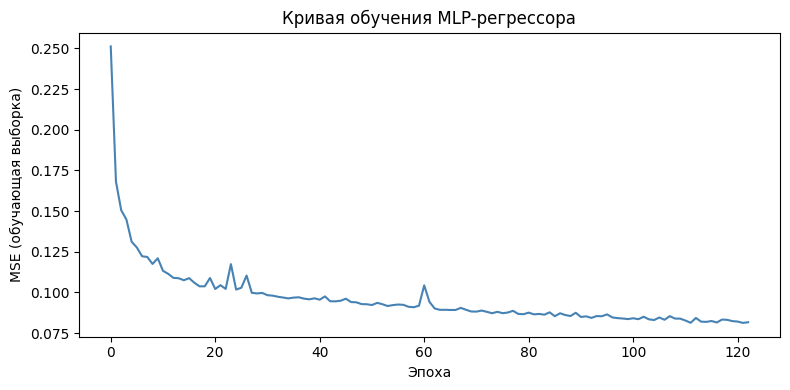

Начальное значение потерь: 0.2512
Финальное значение потерь: 0.0817


In [15]:
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color='steelblue', linewidth=1.5)
plt.xlabel('Эпоха')
plt.ylabel('MSE (обучающая выборка)')
plt.title('Кривая обучения MLP-регрессора')
plt.tight_layout()
plt.show()

print(f"Начальное значение потерь: {mlp.loss_curve_[0]:.4f}")
print(f"Финальное значение потерь: {mlp.loss_curve_[-1]:.4f}")

## Влияние масштабирования

Сравним качество модели с масштабированием и без.

In [16]:
mlp_unscaled = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp_unscaled.fit(X_train, y_train)
y_pred_unscaled = mlp_unscaled.predict(X_test)
r2_unscaled = r2_score(y_test, y_pred_unscaled)
rmse_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_unscaled))

r2_scaled = r2_score(y_test, y_pred)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred))

df_scaling = pd.DataFrame([
    {'Вариант': 'Без масштабирования', 'R²': round(r2_unscaled, 4), 'RMSE': round(rmse_unscaled, 4)},
    {'Вариант': 'С масштабированием',  'R²': round(r2_scaled,   4), 'RMSE': round(rmse_scaled,   4)},
])

print("Влияние масштабирования на качество MLP-регрессора:")
df_scaling

Влияние масштабирования на качество MLP-регрессора:


,Вариант,R²,RMSE
0,Без масштабирования,-12.3638,4.1847
1,С масштабированием,0.7979,0.5146


## Анализ остатков

**Остаток** — это разница между предсказанным и истинным значением: $e_i = \hat{y}_i - y_i$.

Анализ остатков помогает понять, есть ли у модели систематические ошибки:

- **Гистограмма остатков** — в идеале симметрична и центрирована около 0. Если смещена вправо — модель переоценивает, влево — недооценивает.
- **Остатки vs предсказания** (scatter) — точки должны быть равномерно разбросаны вокруг 0. Если видна закономерность (воронка, дуга) — модель не улавливает какую-то зависимость в данных.

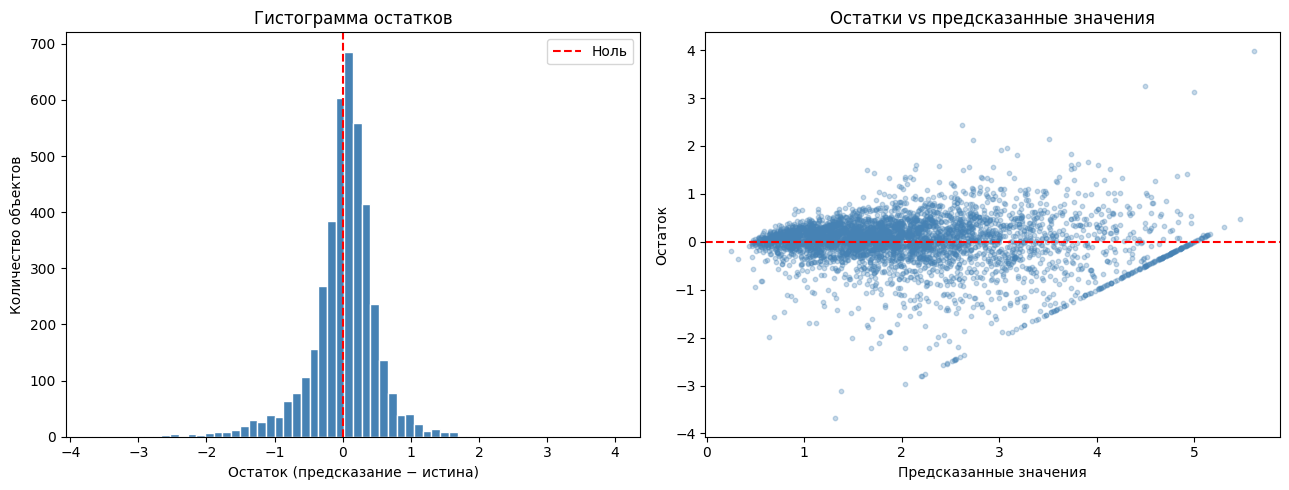

Среднее остатков:         0.0153
Стд. отклонение остатков: 0.5144


In [17]:
residuals = y_pred - y_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Ноль')
axes[0].set_xlabel('Остаток (предсказание − истина)')
axes[0].set_ylabel('Количество объектов')
axes[0].set_title('Гистограмма остатков')
axes[0].legend()

axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остаток')
axes[1].set_title('Остатки vs предсказанные значения')

plt.tight_layout()
plt.show()

print(f"Среднее остатков:         {residuals.mean():.4f}")
print(f"Стд. отклонение остатков: {residuals.std():.4f}")